# Mask-alignment verification (RF ↔ DICOM ↔ pipeline)

Sanity check that the lesion **mask is applied at the correct location**, cross-checking against an independent reconstruction from the raw **RF**.

Two annotation types live in **different coordinate spaces**:
- **spline mask** → the **DICOM scan-converted** (fan) image — what our pipeline uses;
- **GUI box** → the **RF pre-scan grid** (rectangular lines×samples).

The DICOM *is* the scanner's reconstruction from RF (RF → beamform → **scan-convert** → display). So if the box (from RF) and the mask (on the DICOM) land on the same lesion, placement is correct. Per case: **A** native RF + box · **B** scan-converted RF + box · **C** raw DICOM + mask · **D** our pipeline crop + mask.

In [1]:
%matplotlib inline
import glob, warnings; warnings.simplefilter('ignore')
import numpy as np, matplotlib.pyplot as plt, pydicom
from usloc import config as C
from usloc.data.discover import find_case_dir, list_dicoms, list_extracted
from usloc.io import parse_rawdata_yml, read_raw, read_dicom
from usloc.recon import rf_to_bmode, scan_convert, sector_angle_rad
from usloc.labels import load_boxes, load_spline, rasterize_spline, register_case
from usloc.deid import ultrasound_region
from usloc.viz import show_gray, draw_box, overlay_mask
plt.rcParams.update({'figure.dpi':110,'font.size':9,'axes.titlesize':8,'figure.facecolor':'white'})

def pick_c3(case):
    '''C3 preset with the most scan lines (widest FOV) that has a native _rf.raw.'''
    best = None
    for e in list_extracted(find_case_dir(case)):
        for pre, roles in e.presets.items():
            if pre.startswith('C3') and 'rf_raw' in roles and 'rf_yml' in roles:
                g = parse_rawdata_yml(roles['rf_yml'])
                if best is None or g.number_of_lines > best[0].number_of_lines:
                    best = (g, roles)
    return best

def small_box(case):
    bs = load_boxes(glob.glob(str(C.GUI_ROOT/'gui_*'/f'{case}.xlsx'))[0])
    return next((b for b in bs if b.roi_kind=='small'), bs[0])


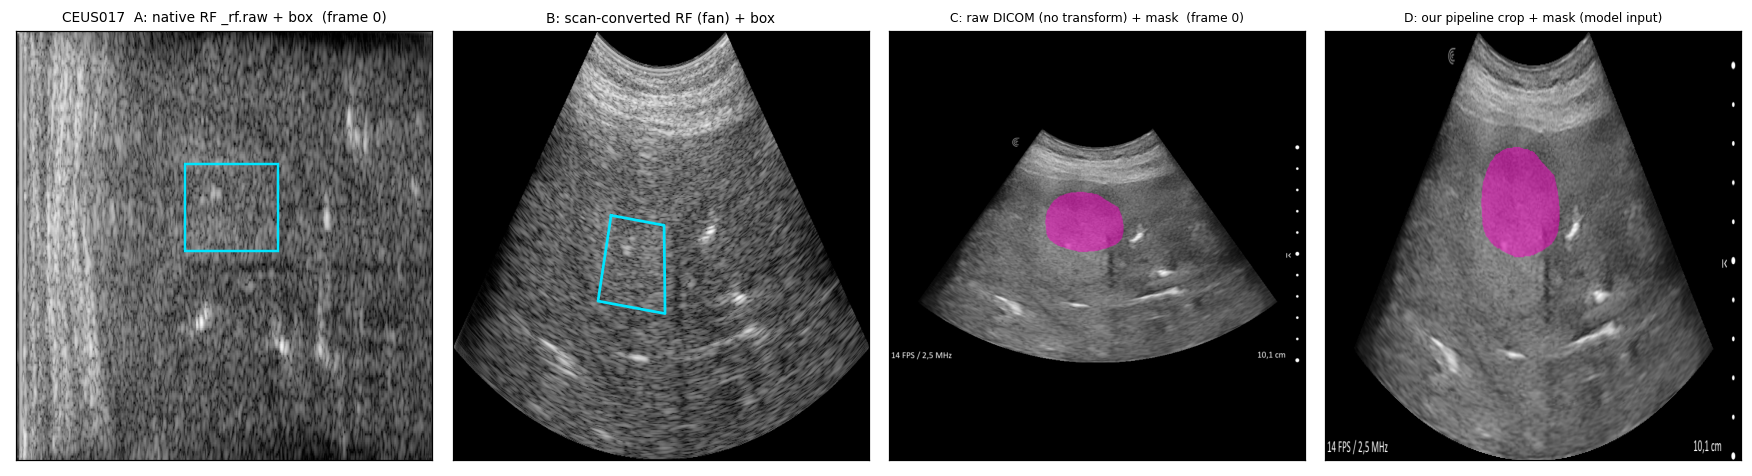

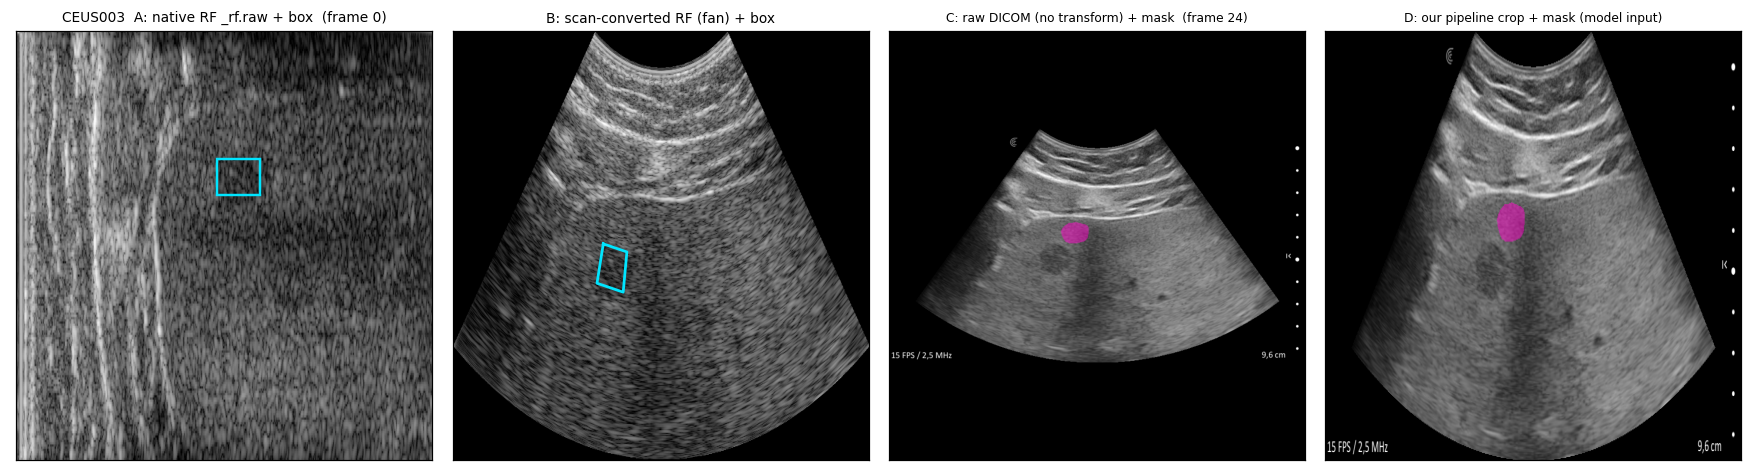

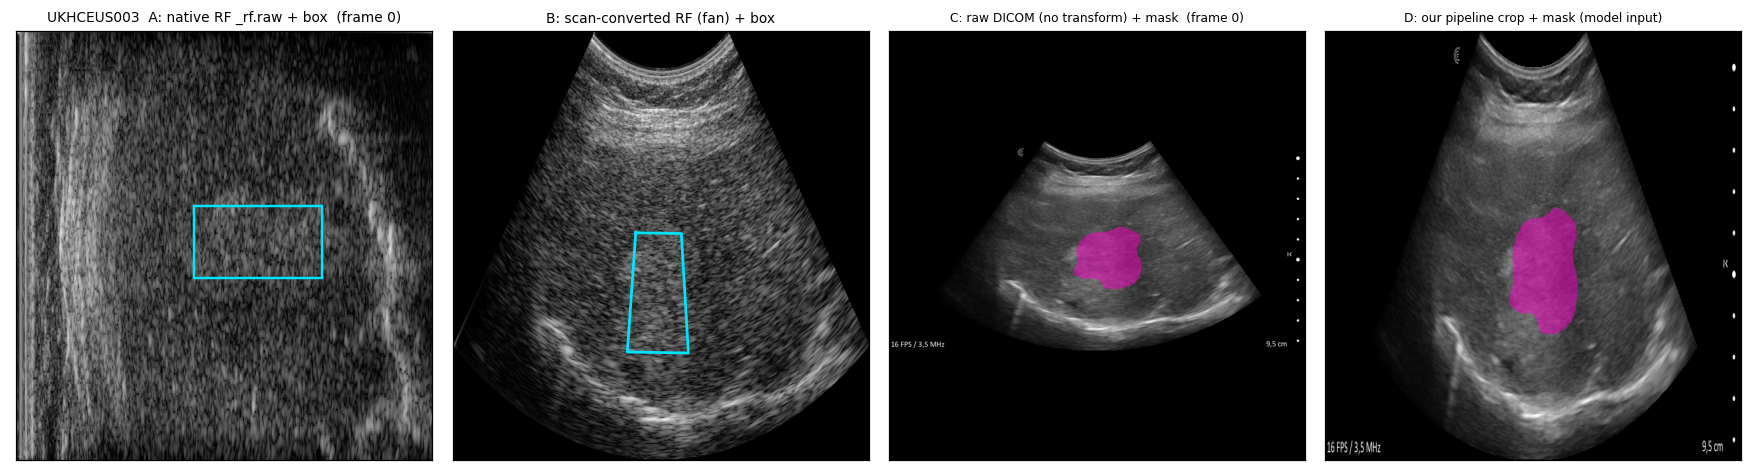

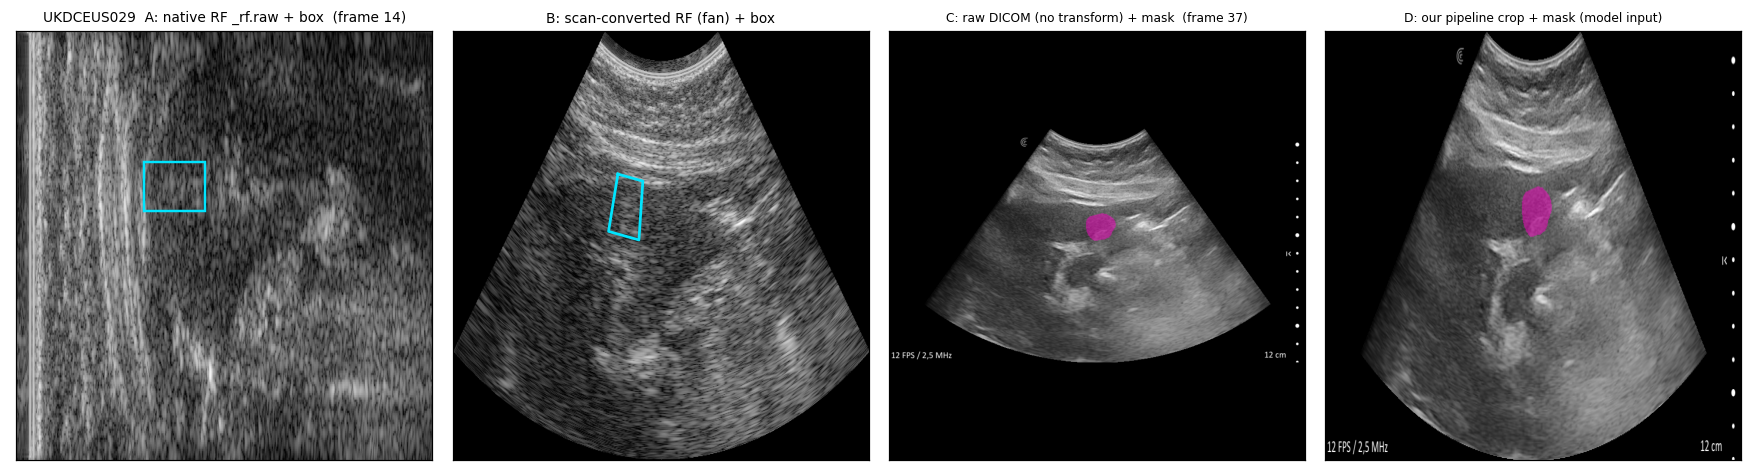

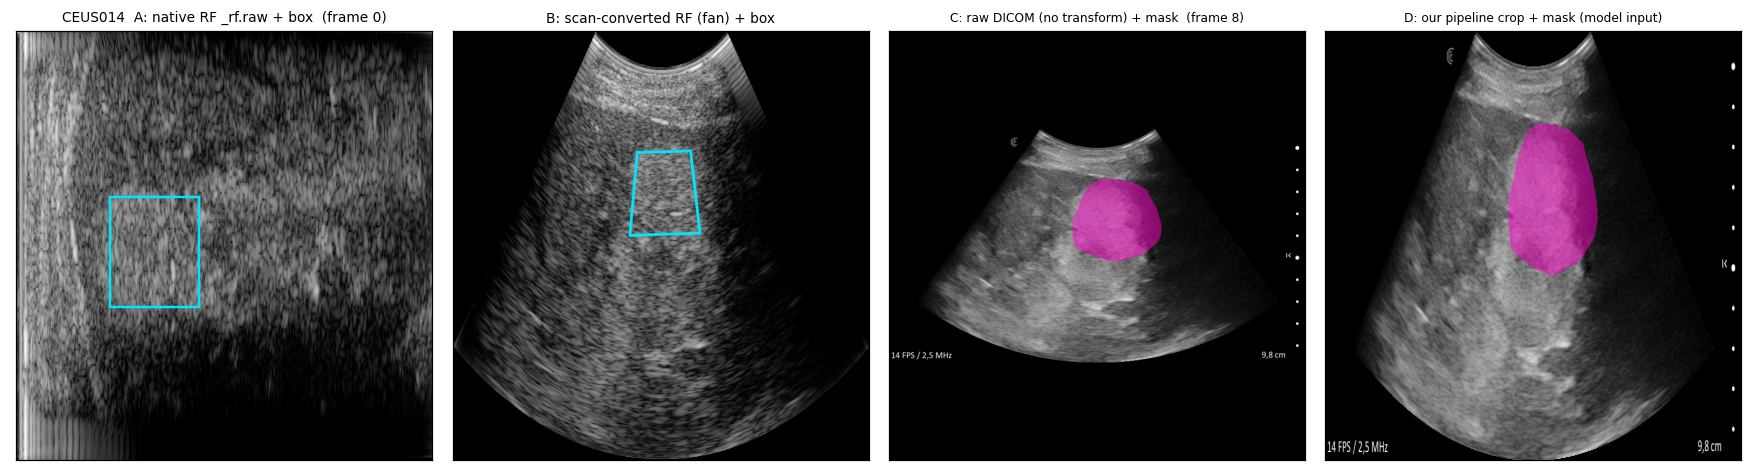

In [2]:
def alignment_row(case):
    g, roles = pick_c3(case)
    rf = read_raw(roles['rf_raw'], g)                 # (frames, lines, samples) native RF
    box = small_box(case); h1,v1,h2,v2 = box.xyxy     # h=sample, v=line (RF grid)
    bf = min(box.frame, rf.shape[0]-1)
    prescan = rf_to_bmode(rf[bf], axis=1)             # (lines, samples)
    sect = sector_angle_rad(g.number_of_lines, g.probe_pitch_um, g.probe_radius_mm)
    fan, fwd = scan_convert(prescan, radius_mm=g.probe_radius_mm, depth_mm=g.imaging_depth_mm,
                            sector_rad=sect, out_h=560)
    corners = np.array([fwd(v,h) for v,h in [(v1,h1),(v1,h2),(v2,h2),(v2,h1),(v1,h1)]])
    # DICOM + mask (no transform) and pipeline crop + mask
    d = [p for p in list_dicoms(find_case_dir(case)) if p.name.startswith('0_0')][0]
    ds, frames = read_dicom(d, deidentify=True)
    reg = ultrasound_region(pydicom.dcmread(str(d)))
    sp = load_spline(str(C.FLL_ROI_DIR/f'{case}_roi.pkl')); sf = min(sp.frame, frames.shape[0]-1)
    maskD = rasterize_spline(np.asarray(sp.x)+reg.x0, np.asarray(sp.y)+reg.y0, frames.shape[1:])
    s = register_case(case, space='crop')

    fig, ax = plt.subplots(1, 4, figsize=(16, 4.4))
    show_gray(ax[0], prescan, f'{case}  A: native RF _rf.raw + box  (frame {bf})')
    draw_box(ax[0], (h1,v1,h2,v2), '#00e5ff')
    show_gray(ax[1], fan, 'B: scan-converted RF (fan) + box')
    ax[1].plot(corners[:,0], corners[:,1], '-', color='#00e5ff', lw=1.8)
    ax[2].imshow(overlay_mask(frames[sf], maskD, (255,0,200), 0.5), aspect='auto')
    ax[2].set_title(f'C: raw DICOM (no transform) + mask  (frame {sf})'); ax[2].set_xticks([]); ax[2].set_yticks([])
    ax[3].imshow(overlay_mask(s.image, s.mask, (255,0,200), 0.5), aspect='auto')
    ax[3].set_title('D: our pipeline crop + mask (model input)'); ax[3].set_xticks([]); ax[3].set_yticks([])
    plt.tight_layout(); plt.show()

cases = ['CEUS017', 'CEUS003', 'UKHCEUS003', 'UKDCEUS029', 'CEUS014']
for c in cases:
    try:
        alignment_row(c)
    except Exception as e:
        print(f'{c}: skipped ({type(e).__name__}: {e})')


## Verdict
- **The mask is applied correctly.** In every row, panels **C** (raw DICOM, no transform) and **D** (our pipeline crop) place the mask on the same visible lesion — and D is just C cropped, so the pipeline preserves the location (no resize/shift bug).
- **The independent RF box agrees.** Reconstructing from the native `_rf.raw` and scan-converting (**B**) reproduces the DICOM fan, and the box lands on the same lesion — so the two annotations, in two different coordinate systems, point to the same anatomy.
- **Caveats (not bugs):** overlaying the spline mask directly on the *native* RF pre-scan (A) would not line up — that is the scan-conversion geometry difference. The scan-conversion here is approximate (radius/angle from the YAML, no vendor calibration); use the native `_rf.raw` (1920 samples), **not** the `_rf_no_tgc.npy` (2928 samples, resampled), for correct axial scaling.